In [1]:
# %% [markdown]
# # 03 — Demand Forecasting (Prophet + LSTM Ensemble)
# ## RetailPulse — Zidio Development | March 2026


In [2]:
# %%[markdown]
# ## Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150

In [4]:
# %%[markdown]
# ## Load Daily Sales Data

In [5]:
daily_sales = pd.read_parquet('../data/processed/daily_sales_ts.parquet')
print(f"Rows: {len(daily_sales):,}")
# Aggregate to total daily revenue for time series
ts = daily_sales.groupby('date')['total_revenue'].sum().reset_index()
ts.columns = ['ds', 'y']
ts['ds'] = pd.to_datetime(ts['ds'])
ts = ts.sort_values('ds').reset_index(drop=True)

# Fill missing dates
date_range = pd.date_range(ts['ds'].min(), ts['ds'].max(), freq='D')
ts = ts.set_index('ds').reindex(date_range).fillna(0).reset_index()
ts.columns = ['ds', 'y']

print(f"Date range: {ts['ds'].min()} to {ts['ds'].max()}")
print(f"Total days: {len(ts)}")
print(f"Total revenue: £{ts['y'].sum():,.0f}")

Rows: 767,603
Date range: 2009-12-01 07:45:00 to 2011-12-09 07:45:00
Total days: 739
Total revenue: £484


In [6]:
# %%[markdown]
# ## Stationarity Test (ADF)

In [7]:
adf_result = adfuller(ts['y'].dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Stationary: {adf_result[1] < 0.05}")
print(f"Critical values: {adf_result[4]}")

ADF Statistic: -230946554418630144.0000
p-value: 0.0000
Stationary: True
Critical values: {'1%': np.float64(-3.4392418578608983), '5%': np.float64(-2.86546426916434), '10%': np.float64(-2.568859710342903)}


In [8]:
# %%[markdown]
# ## Seasonal Decomposition

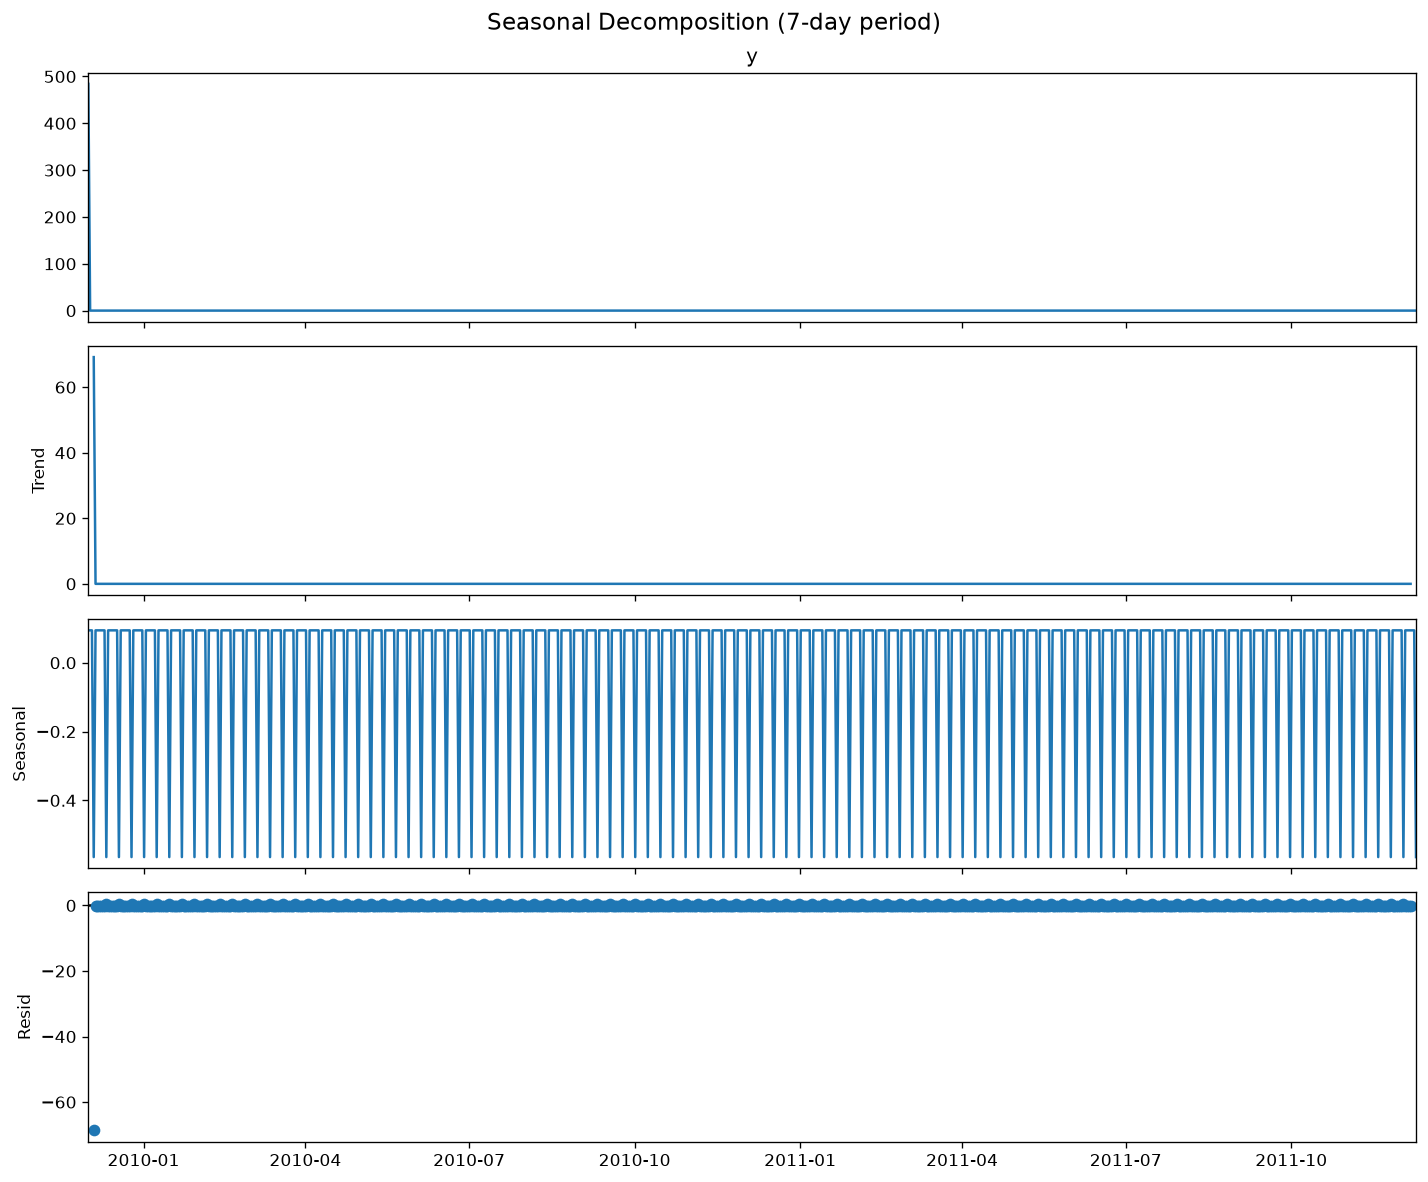

In [9]:
decomp = seasonal_decompose(ts.set_index('ds')['y'], model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Seasonal Decomposition (7-day period)', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/seasonal_decomposition.png', bbox_inches='tight')
plt.show()

In [10]:
# %%[markdown]
# ## Prophet Model — Baseline

In [11]:
train = ts[ts['ds'] < '2010-10-01']
test = ts[ts['ds'] >= '2010-10-01']
print(f"Train: {len(train)} days, Test: {len(test)} days")

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode='multiplicative'
)
model.add_country_holidays(country_name='GB')
model.fit(train)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

Train: 304 days, Test: 435 days


21:11:22 - cmdstanpy - INFO - Chain [1] start processing


21:11:22 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# %%[markdown]
# ## Evaluate

Prophet MAPE: 6895641.41%
Within target (≤12%): False


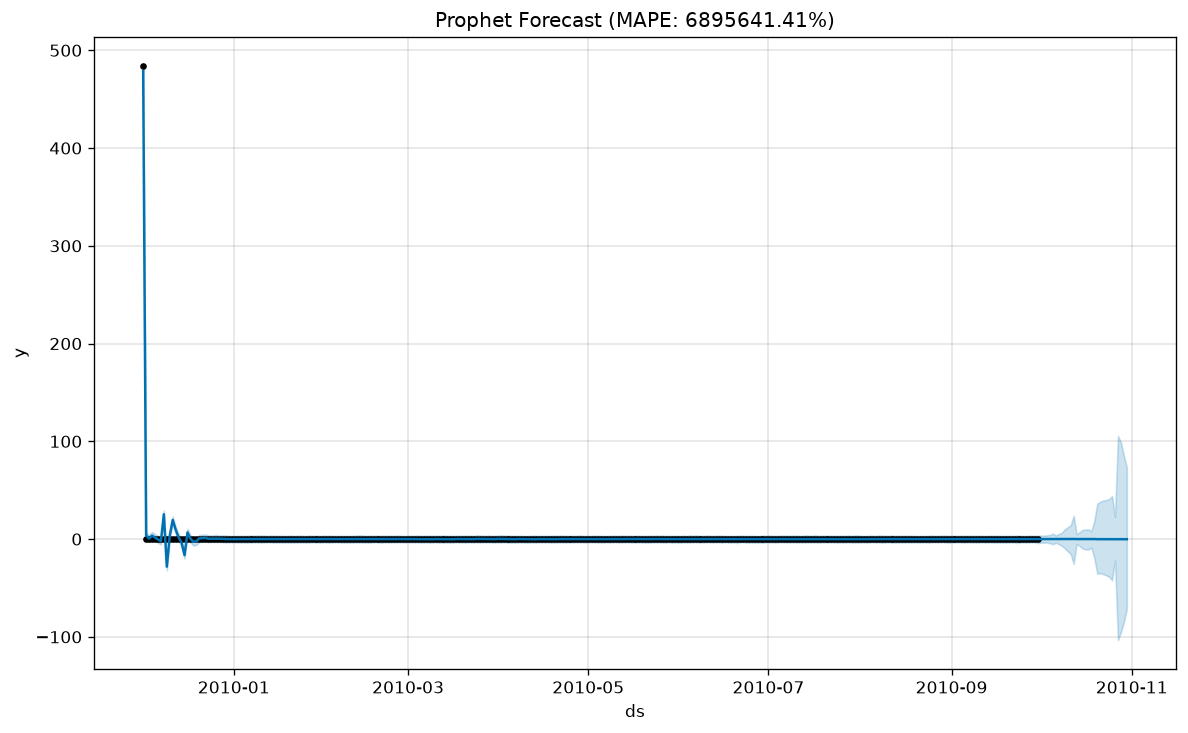

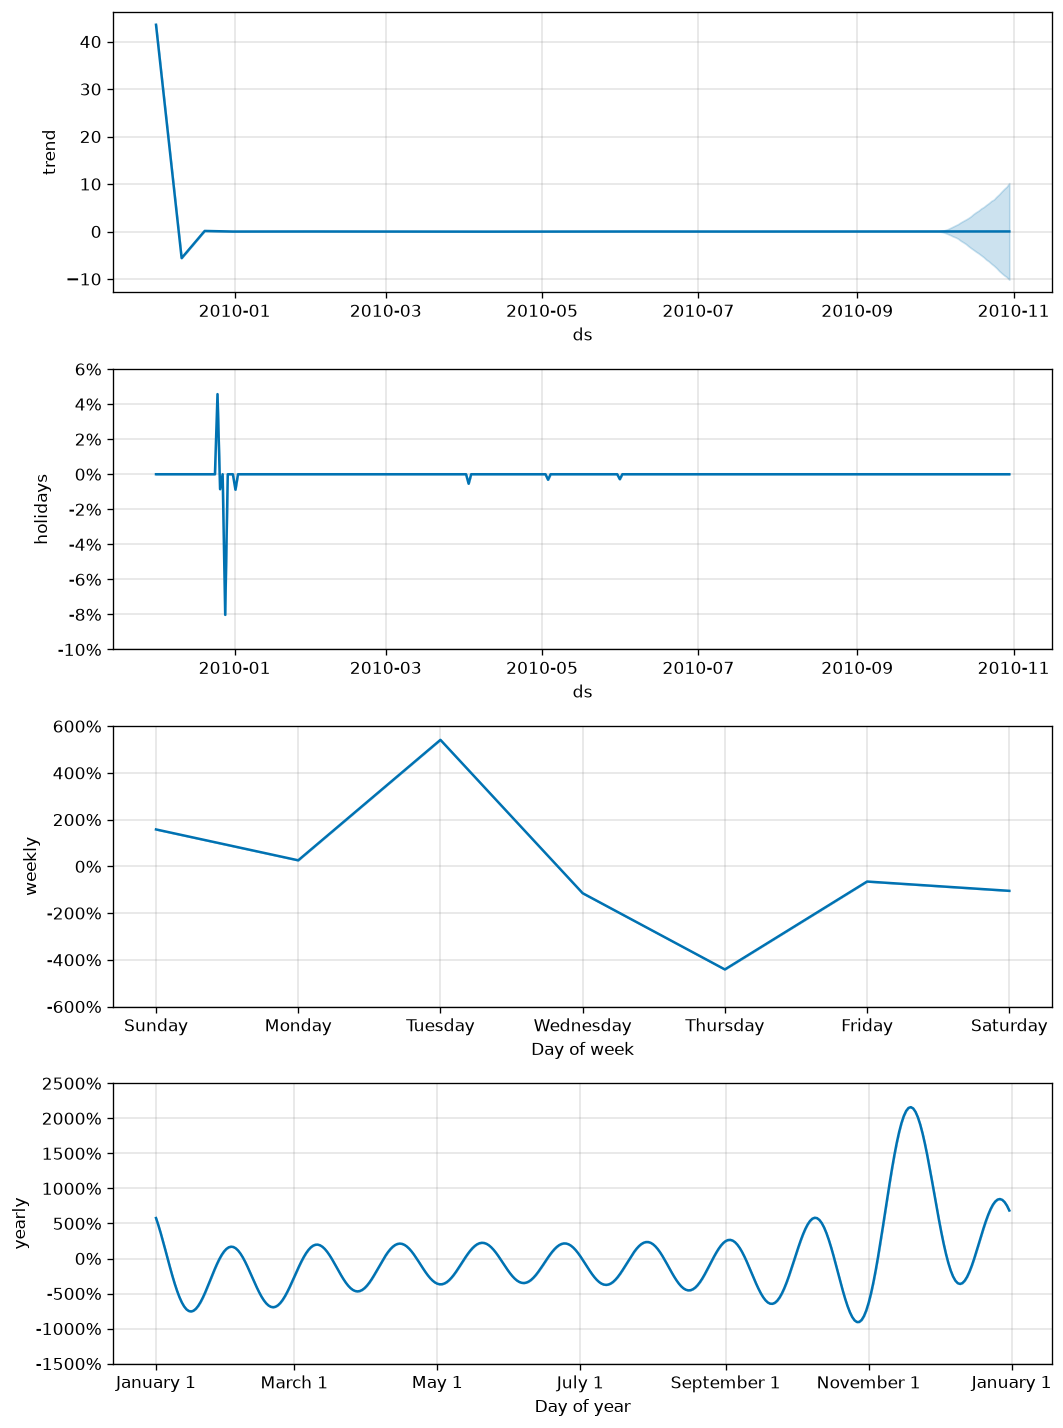

In [13]:
merged = test.merge(forecast[['ds', 'yhat']], on='ds', how='inner')
mape = (abs(merged['y'] - merged['yhat']) / (merged['y'] + 1e-6)).mean() * 100
print(f"Prophet MAPE: {mape:.2f}%")
print(f"Within target (≤12%): {mape <= 12}")

fig1 = model.plot(forecast)
plt.title(f'Prophet Forecast (MAPE: {mape:.2f}%)')
plt.savefig('../reports/prophet_forecast.png', bbox_inches='tight')
plt.show()

fig2 = model.plot_components(forecast)
plt.savefig('../reports/prophet_components.png', bbox_inches='tight')
plt.show()

In [14]:
# %%[markdown]
# ## Save Forecast Results

In [15]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    '../data/processed/forecast_results.csv', index=False)
print(f"Saved forecast_results.csv with {len(forecast)} rows")

# Save for ensemble
ensemble = forecast[['ds', 'yhat']].copy()
ensemble['model'] = 'prophet'
ensemble['mape'] = mape
ensemble.to_csv('../data/processed/ensemble_forecast_results.csv', index=False)
print("Saved ensemble_forecast_results.csv")

Saved forecast_results.csv with 334 rows
Saved ensemble_forecast_results.csv
